# Taller Análisis Exploratorio de Datos

Neithan Felipe Gomez Rivera - 1013338680
Daniela Higuita Agudelo - 1027801607

## Paso 1: Carga de datos

Abra el archivo en Excel o bloc de notas, y revise sí hay algo particular con los datos. Este paso es importante para evitar problemas posteriores al cargar los datos.

Cargar el archivo dado, que contiene un dataset cuya información puede consultar en [IBM](https://community.ibm.com/community/user/businessanalytics/blogs/steven-macko/2019/07/11/telco-customer-churn-1113).

Responda las siguientes preguntas:

- ¿Cuántas filas y columnas tiene el dataframe?
- ¿De qué tipo de dato es cada columna?
- ¿Las variables están en el tipo de dato correcto para su contenido?


In [22]:
from pathlib import Path
import pandas as pd

ROOT_DIR = Path().resolve().parent
DATA_DIR = ROOT_DIR / "data/raw"
file_path = 'Telco_customer_churn.csv'

df = pd.read_csv(DATA_DIR / file_path)
df.head()


,CustomerID,Count,Country,State,City,Zip Code,Lat Long,Latitude,Longitude,Gender,...,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Churn Label,Churn Value,Churn Score,CLTV,Churn Reason
0,3668-QPYBK,1,United States,California,Los Angeles,90003,"33.964131, -118.272783",33.964131,-118.272783,Male,...,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,1,86,3239,Competitor made better offer
1,9237-HQITU,1,United States,California,Los Angeles,90005,"34.059281, -118.30742",34.059281,-118.307420,Female,...,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,1,67,2701,Moved
2,9305-CDSKC,1,United States,California,Los Angeles,90006,"34.048013, -118.293953",34.048013,-118.293953,Female,...,Month-to-month,Yes,Electronic check,99.65,820.5,Yes,1,86,5372,Moved
3,7892-POOKP,1,United States,California,Los Angeles,90010,"34.062125, -118.315709",34.062125,-118.315709,Female,...,Month-to-month,Yes,Electronic check,104.80,3046.05,Yes,1,84,5003,Moved
4,0280-XJGEX,1,United States,California,Los Angeles,90015,"34.039224, -118.266293",34.039224,-118.266293,Male,...,Month-to-month,Yes,Bank transfer (automatic),103.70,5036.3,Yes,1,89,5340,Competitor had better devices


#### <span style="color:green"> 1.Con df.info resuelvo la primera pregunta, son 7043 filas y 33 columnas  </span>
#### <span style="color:green"> 2.Tambien se resuelve la segunda pregunta, del tipo de datos de todos, habiendo estos tipos float64(3), int64(6), object(24)  </span>
#### <span style="color:green"> 3. Hay una que no esta en el tipo que debe, Total charges deberia de ser tipo numerica y no categorica  </span>




In [23]:

df.info()

# para la tercera pregunta, hay algunas variables con el tipo de datos erroneo, por ejemplo customerID, que no deberia de ser un objeto.


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 33 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   CustomerID         7043 non-null   object 
 1   Count              7043 non-null   int64  
 2   Country            7043 non-null   object 
 3   State              7043 non-null   object 
 4   City               7043 non-null   object 
 5   Zip Code           7043 non-null   int64  
 6   Lat Long           7043 non-null   object 
 7   Latitude           7043 non-null   float64
 8   Longitude          7043 non-null   float64
 9   Gender             7043 non-null   object 
 10  Senior Citizen     7043 non-null   object 
 11  Partner            7043 non-null   object 
 12  Dependents         7043 non-null   object 
 13  Tenure Months      7043 non-null   int64  
 14  Phone Service      7043 non-null   object 
 15  Multiple Lines     7043 non-null   object 
 16  Internet Service   7043 

#### <span style="color:green"> Cambio el tipo del Total Charges  </span>


In [24]:
df['Total Charges'] = pd.to_numeric(df['Total Charges'], errors='coerce')
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 33 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   CustomerID         7043 non-null   object 
 1   Count              7043 non-null   int64  
 2   Country            7043 non-null   object 
 3   State              7043 non-null   object 
 4   City               7043 non-null   object 
 5   Zip Code           7043 non-null   int64  
 6   Lat Long           7043 non-null   object 
 7   Latitude           7043 non-null   float64
 8   Longitude          7043 non-null   float64
 9   Gender             7043 non-null   object 
 10  Senior Citizen     7043 non-null   object 
 11  Partner            7043 non-null   object 
 12  Dependents         7043 non-null   object 
 13  Tenure Months      7043 non-null   int64  
 14  Phone Service      7043 non-null   object 
 15  Multiple Lines     7043 non-null   object 
 16  Internet Service   7043 

## Paso 2: Exploración inicial de los datos

Responda las siguientes preguntas:

- ¿Hay valores fuera de rango o imposibles, según el dominio del problema?
- ¿Hay variables que no varían?
- Qué variables *cualitativas* tienen muchos valores únicos (alta cardinalidad)?
- ¿Hay claves primarias o identificadores únicos?

#### <span style="color:green"> 1. El minimo y el maximo estan constantes y la desviacion estandar es 0 por ende no hay valores fuera de rango</span>

In [25]:
df.describe()

,Count,Zip Code,Latitude,Longitude,Tenure Months,Monthly Charges,Total Charges,Churn Value,Churn Score,CLTV
count,7043.0,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7032.000000,7043.000000,7043.000000,7043.000000
mean,1.0,93521.964646,36.282441,-119.798880,32.371149,64.761692,2283.300441,0.265370,58.699418,4400.295755
std,0.0,1865.794555,2.455723,2.157889,24.559481,30.090047,2266.771362,0.441561,21.525131,1183.057152
min,1.0,90001.000000,32.555828,-124.301372,0.000000,18.250000,18.800000,0.000000,5.000000,2003.000000
25%,1.0,92102.000000,34.030915,-121.815412,9.000000,35.500000,401.450000,0.000000,40.000000,3469.000000
50%,1.0,93552.000000,36.391777,-119.730885,29.000000,70.350000,1397.475000,0.000000,61.000000,4527.000000
75%,1.0,95351.000000,38.224869,-118.043237,55.000000,89.850000,3794.737500,1.000000,75.000000,5380.500000
max,1.0,96161.000000,41.962127,-114.192901,72.000000,118.750000,8684.800000,1.000000,100.000000,6500.000000


#### <span style="color:green">  2. Si hay variables que no varian por ejemplo el country que solo dice estados unidos, lo vemos con el unique </span>

#### <span style="color:green"> 3. Tambien vemos que hay variables con una cardinalidad altisima como por ejemplo </span>
    City                 1129
    Zip Code             1652
    Lat Long             1652
    Latitude             1652
    Longitude            1651
    CLTV                 3438
    Monthly Charges      1585
    Total Charges        6530

In [26]:
# Ver posibles constantes y cardinalidad
print(df.nunique())



CustomerID           7043
Count                   1
Country                 1
State                   1
City                 1129
Zip Code             1652
Lat Long             1652
Latitude             1652
Longitude            1651
Gender                  2
Senior Citizen          2
Partner                 2
Dependents              2
Tenure Months          73
Phone Service           2
Multiple Lines          3
Internet Service        3
Online Security         3
Online Backup           3
Device Protection       3
Tech Support            3
Streaming TV            3
Streaming Movies        3
Contract                3
Paperless Billing       2
Payment Method          4
Monthly Charges      1585
Total Charges        6530
Churn Label             2
Churn Value             2
Churn Score            85
CLTV                 3438
Churn Reason           20
dtype: int64


#### <span style="color:green"> 4. Solo hay una columna que es una identificadora unica, el CustomerID, lo hago comparando  el nunique con el len  </span>

In [27]:
posibles_ids = [col for col in df.columns if df[col].nunique() == len(df)]
print(f"Columnas que son identificadores únicos: {posibles_ids}")

Columnas que son identificadores únicos: ['CustomerID']


## Paso 3: Identificación de datos duplicados, datos nulos y problemas de formateo

Descarte las variables que solo toman un valor y las que son clave primaria. También descarte las variables **City** y **Lat Long**.

Responda las siguientes preguntas:

- ¿Qué variables tienen valores nulos? ¿En qué proporción?
- ¿Hay registros duplicados?
- ¿Hay variables con problemas de formateo (fechas, monedas, mayúsculas/minúsculas)?

#### <span style="color:green">  Primero descartamos las columnas </span>

In [28]:
constantes = [col for col in df.columns if df[col].nunique() <= 1]

claves_primarias = [col for col in df.columns if df[col].nunique() == len(df)]

especificas = ['City', 'Lat Long']

columnas_a_eliminar = list(set(constantes + claves_primarias + especificas))

df_limpio = df.drop(columns=columnas_a_eliminar)

print(f"Columnas eliminadas: {columnas_a_eliminar}")
print(f"Columnas restantes: {df_limpio.columns.tolist()}")

Columnas eliminadas: ['CustomerID', 'Count', 'State', 'City', 'Lat Long', 'Country']
Columnas restantes: ['Zip Code', 'Latitude', 'Longitude', 'Gender', 'Senior Citizen', 'Partner', 'Dependents', 'Tenure Months', 'Phone Service', 'Multiple Lines', 'Internet Service', 'Online Security', 'Online Backup', 'Device Protection', 'Tech Support', 'Streaming TV', 'Streaming Movies', 'Contract', 'Paperless Billing', 'Payment Method', 'Monthly Charges', 'Total Charges', 'Churn Label', 'Churn Value', 'Churn Score', 'CLTV', 'Churn Reason']


#### <span style="color:green"> 1. Churn reason tiene variables nulas. en una proporcion muy grande, 73% de sus datos son nulos, total charges también con 0.156 % </span>

In [29]:
df_limpio.isnull().sum().sort_values(ascending=False)*100/df_limpio.shape[0]



Churn Reason         73.463013
Total Charges         0.156183
Zip Code              0.000000
Gender                0.000000
Senior Citizen        0.000000
Partner               0.000000
Dependents            0.000000
Tenure Months         0.000000
Phone Service         0.000000
Latitude              0.000000
Longitude             0.000000
Internet Service      0.000000
Multiple Lines        0.000000
Online Security       0.000000
Online Backup         0.000000
Streaming TV          0.000000
Streaming Movies      0.000000
Device Protection     0.000000
Tech Support          0.000000
Paperless Billing     0.000000
Contract              0.000000
Monthly Charges       0.000000
Payment Method        0.000000
Churn Label           0.000000
Churn Value           0.000000
Churn Score           0.000000
CLTV                  0.000000
dtype: float64

#### <span style="color:green"> 2. No hay registros duplicados </span>

In [30]:
print('Número de registros duplicados: ', df_limpio.duplicated().sum())

Número de registros duplicados:  0


#### <span style="color:green"> 3. No hay ninguna variable con problemas de formato </span>

In [31]:
for col in df_limpio.select_dtypes(include=["object"]).columns:
    print(f'La columna "{col}" tiene las siguientes categorías: \n {df_limpio[col].unique()} \n')

La columna "Gender" tiene las siguientes categorías: 
 ['Male' 'Female'] 

La columna "Senior Citizen" tiene las siguientes categorías: 
 ['No' 'Yes'] 

La columna "Partner" tiene las siguientes categorías: 
 ['No' 'Yes'] 

La columna "Dependents" tiene las siguientes categorías: 
 ['No' 'Yes'] 

La columna "Phone Service" tiene las siguientes categorías: 
 ['Yes' 'No'] 

La columna "Multiple Lines" tiene las siguientes categorías: 
 ['No' 'Yes' 'No phone service'] 

La columna "Internet Service" tiene las siguientes categorías: 
 ['DSL' 'Fiber optic' 'No'] 

La columna "Online Security" tiene las siguientes categorías: 
 ['Yes' 'No' 'No internet service'] 

La columna "Online Backup" tiene las siguientes categorías: 
 ['Yes' 'No' 'No internet service'] 

La columna "Device Protection" tiene las siguientes categorías: 
 ['No' 'Yes' 'No internet service'] 

La columna "Tech Support" tiene las siguientes categorías: 
 ['No' 'Yes' 'No internet service'] 

La columna "Streaming TV" tiene l

## Paso 4: Análisis de variables cuantitativas

Haga análisis de normalidad de las variables cuantitativas. Indique cuáles variables cumplen con el supuesto de normalidad y cuáles no.

Haga un análisis gráfico de outliers, y como resultado de este indique que variables tienen datos atípicos.

#### <span style="color:green"> 1. Analisis de normalidad : Count cumple el supuesto de normalidad, el resto de variables no</span>

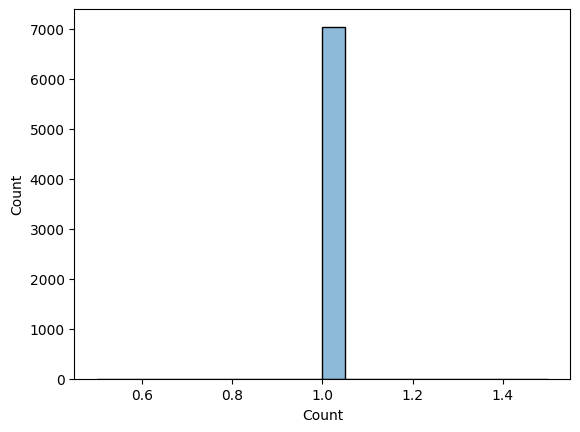

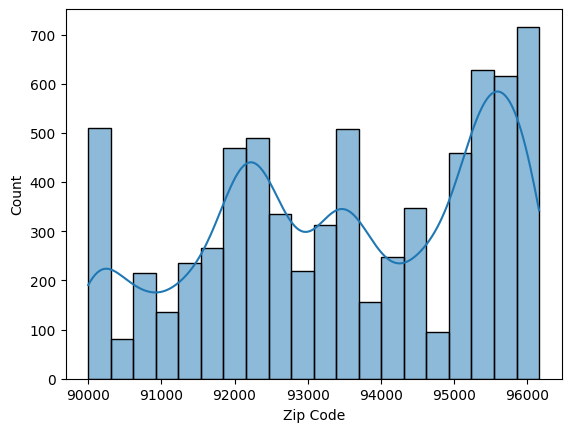

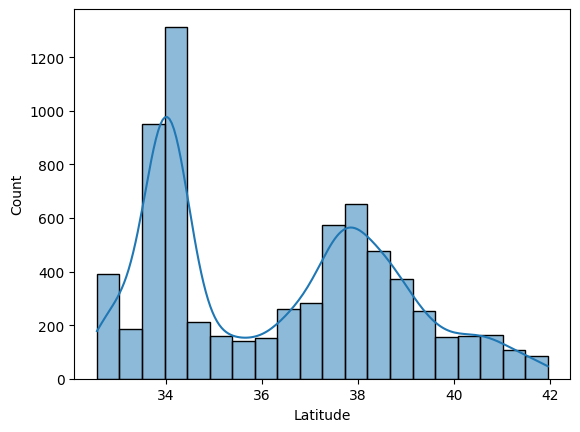

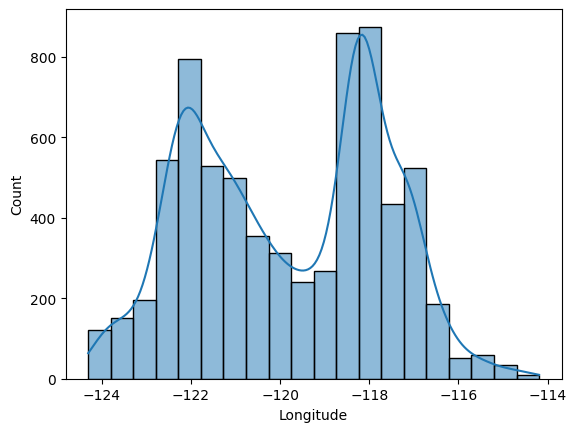

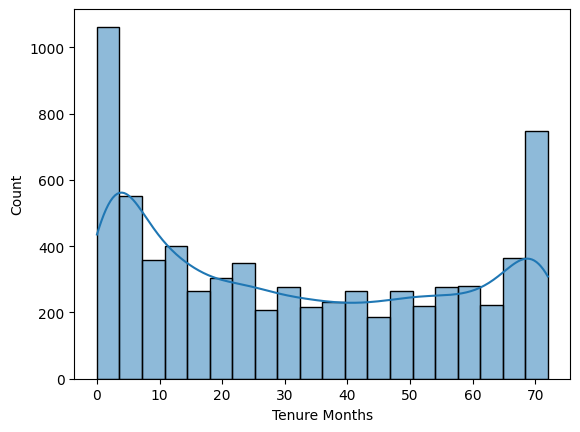

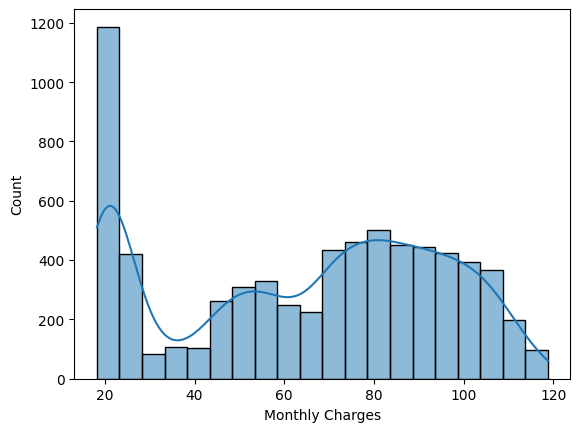

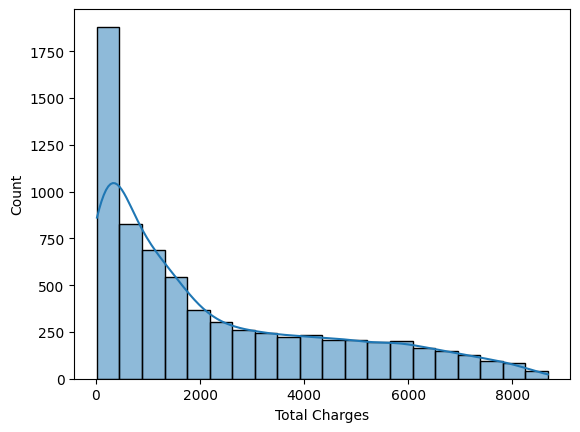

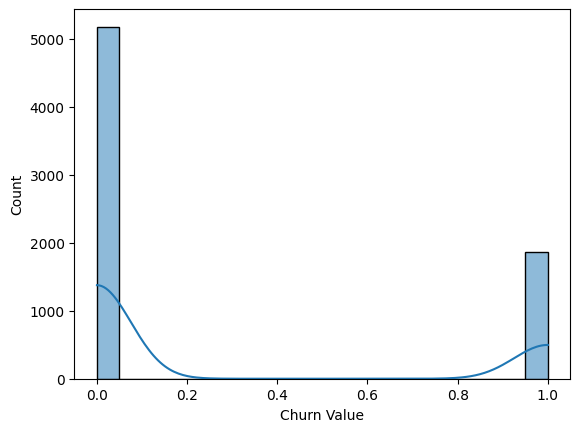

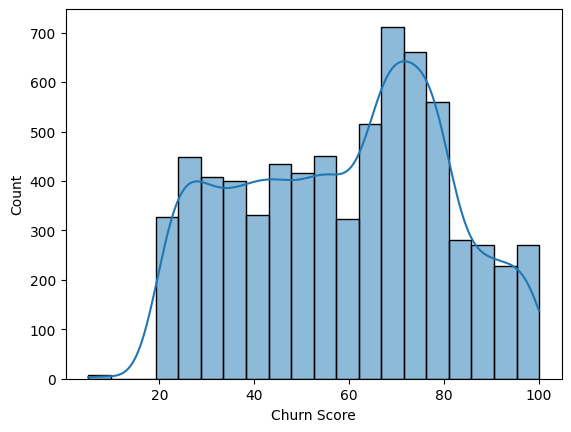

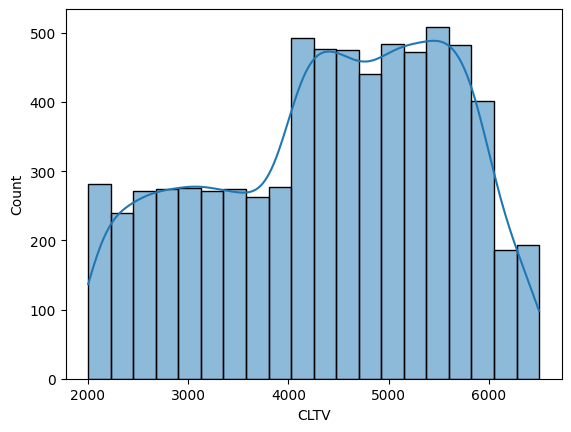

In [32]:
import matplotlib.pyplot as plt
import seaborn as sns

for col in df.select_dtypes(include=['number']).columns:
    plt.figure()
    sns.histplot(data=df, x=col, bins=20, kde=True)
    plt.show()

In [33]:
for num in df.select_dtypes(include=['number']).columns:
    print(f"Asimetría de {num}: {df[num].skew():.3f} \n")

Asimetría de Count: 0.000 

Asimetría de Zip Code: -0.251 

Asimetría de Latitude: 0.304 

Asimetría de Longitude: -0.041 

Asimetría de Tenure Months: 0.240 

Asimetría de Monthly Charges: -0.221 

Asimetría de Total Charges: 0.962 

Asimetría de Churn Value: 1.063 

Asimetría de Churn Score: -0.090 

Asimetría de CLTV: -0.312 



#### <span style="color:green"> 2. Grafico de outliners para datos atipicos: Ninguno tiene datos atipicos</span>

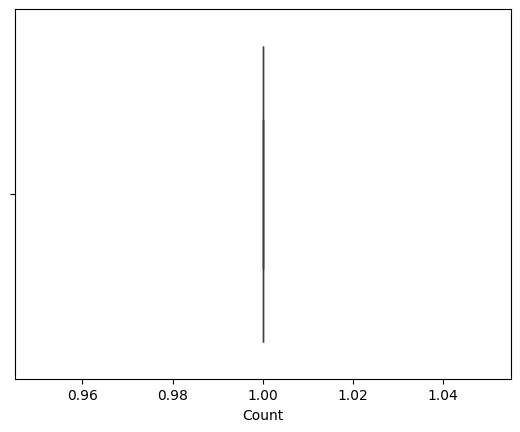

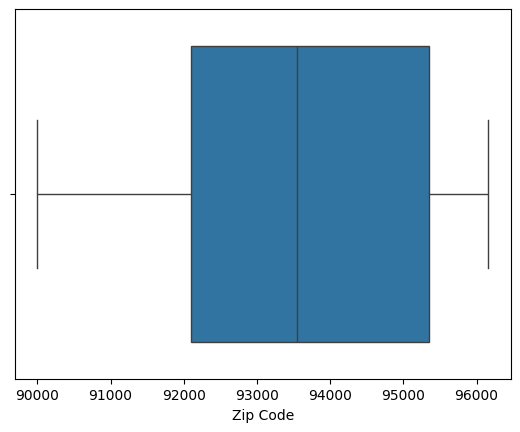

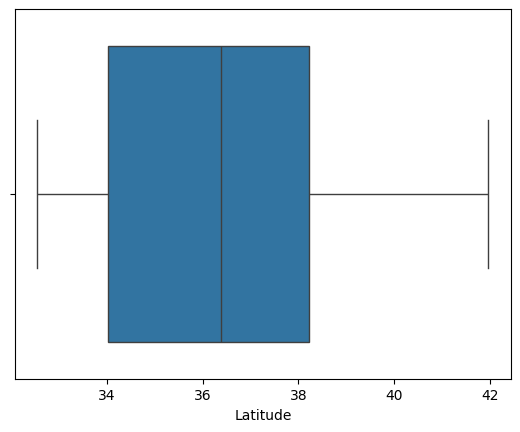

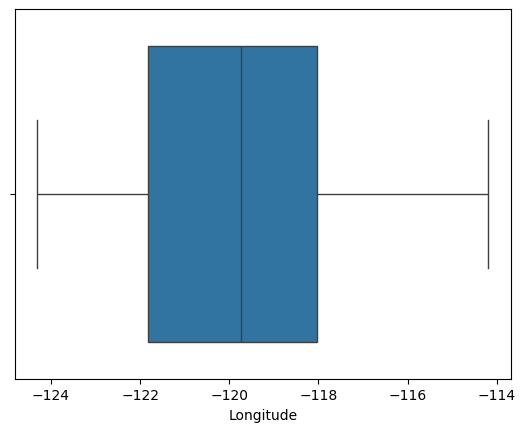

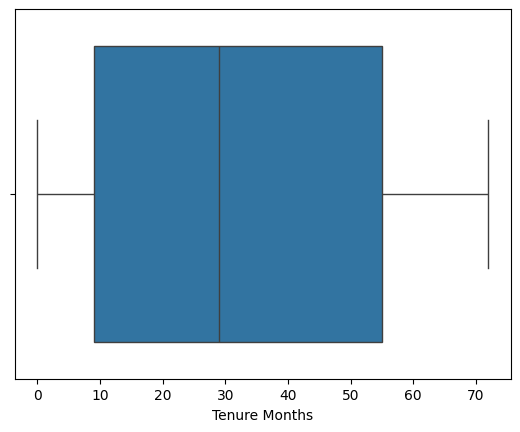

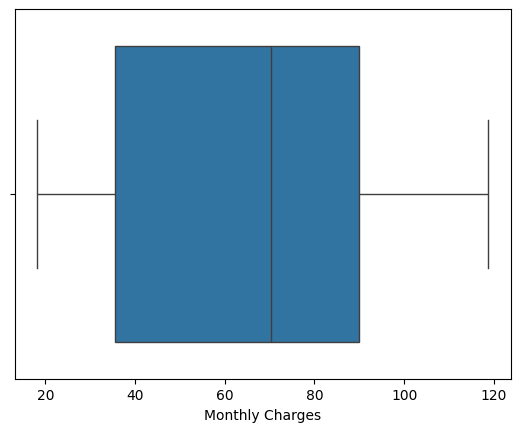

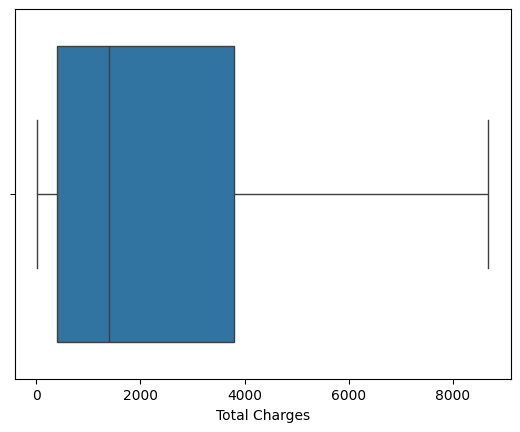

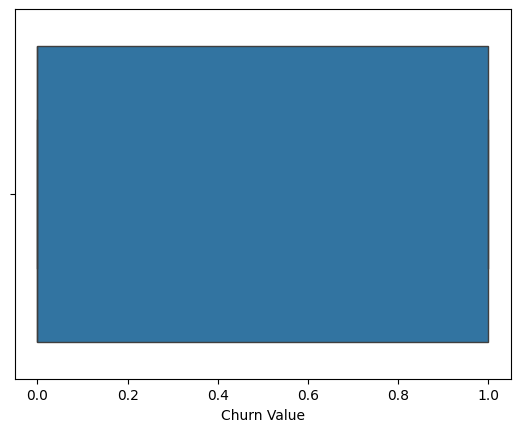

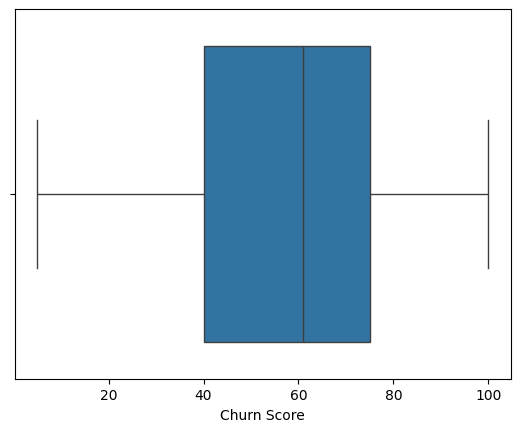

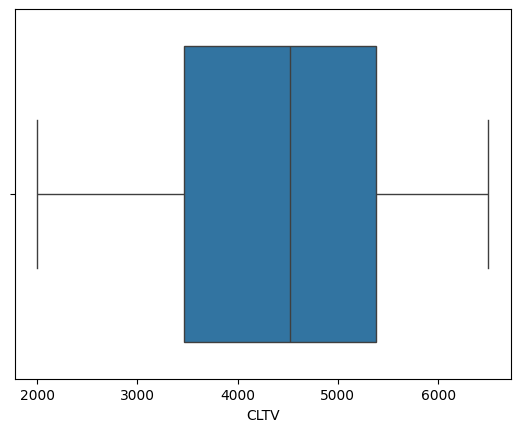

In [34]:
for num in df.select_dtypes(include=['number']).columns:
    plt.figure()
    sns.boxplot(data=df, x=num)
    plt.show();

## Paso 5: Análisis de variables cualitativas

Responda a las siguientes preguntas:

- ¿Cómo se comportan las variables categóricas?
- ¿Existen variables de alta cardinalidad?
- ¿Existen categorías atípicas?

#### <span style="color:green"> La muestra está muy equilibrada en Gender (casi 50/50). Sin embargo, hay pocos Senior Citizens (16%) y pocos clientes con Dependents (23%), La mayoría tiene Phone Service. En Internet Service, la fibra óptica es la más popular.Los servicios de seguridad (Online Security) y soporte técnico (Tech Support) tienen una adopción baja en comparación con el total de usuarios de internet. Contratos y Pagos: Existe una predominancia de contratos Month-to-month (más del 50%).</span>
#### <span style="color:green"> 2.Si, son estas Zip Code,Churn Reason </span>
#### <span style="color:green"> 3.Si, Senior Citizen es un ejemplo, tiene un desbalance, y el deceased tambien, es muy  bajo.  </span>

In [35]:
cat_vars = df_limpio.select_dtypes(include=['object']).columns

for var in cat_vars:
    print(f'El conteo de la variable {var} es: \n {df_limpio[var].value_counts()} \n')

El conteo de la variable Gender es: 
 Gender
Male      3555
Female    3488
Name: count, dtype: int64 

El conteo de la variable Senior Citizen es: 
 Senior Citizen
No     5901
Yes    1142
Name: count, dtype: int64 

El conteo de la variable Partner es: 
 Partner
No     3641
Yes    3402
Name: count, dtype: int64 

El conteo de la variable Dependents es: 
 Dependents
No     5416
Yes    1627
Name: count, dtype: int64 

El conteo de la variable Phone Service es: 
 Phone Service
Yes    6361
No      682
Name: count, dtype: int64 

El conteo de la variable Multiple Lines es: 
 Multiple Lines
No                  3390
Yes                 2971
No phone service     682
Name: count, dtype: int64 

El conteo de la variable Internet Service es: 
 Internet Service
Fiber optic    3096
DSL            2421
No             1526
Name: count, dtype: int64 

El conteo de la variable Online Security es: 
 Online Security
No                     3498
Yes                    2019
No internet service    1526
Name:

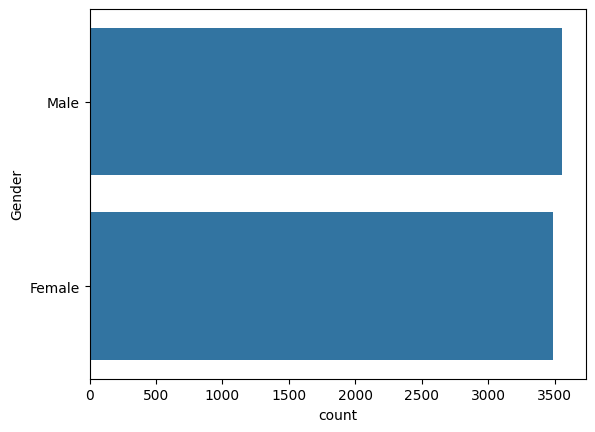

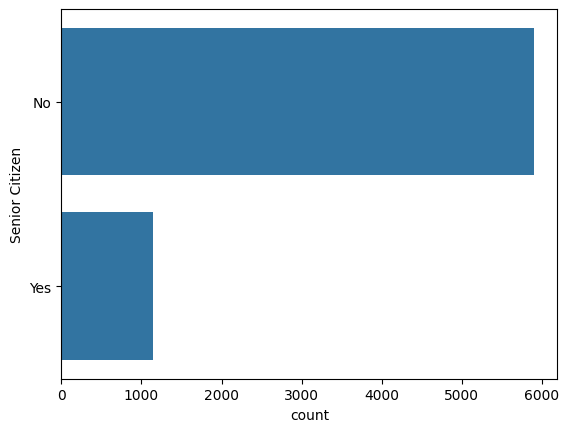

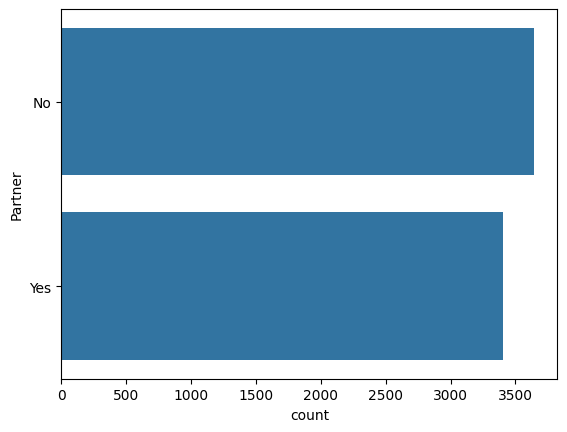

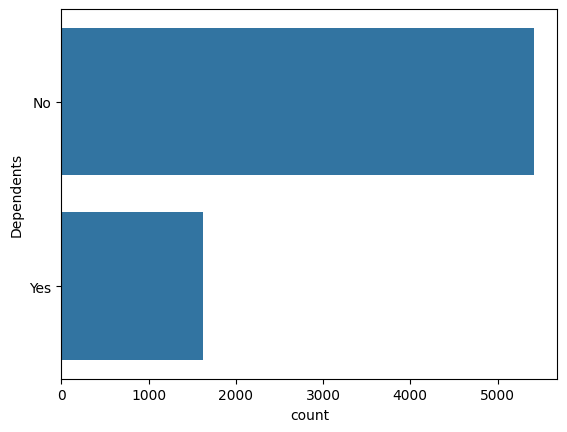

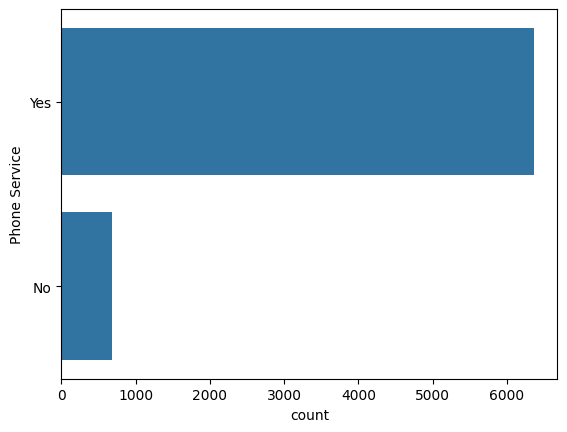

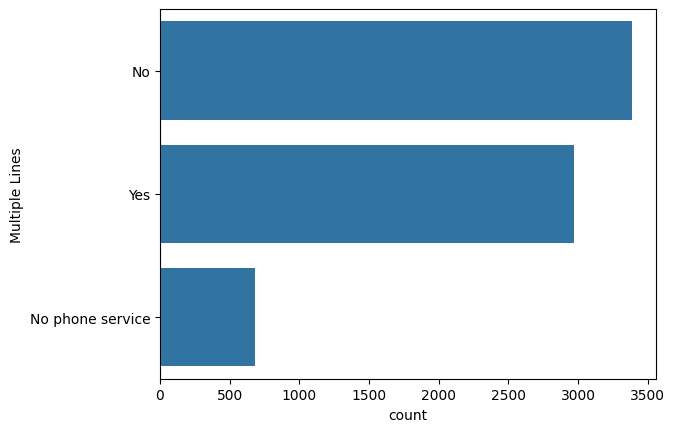

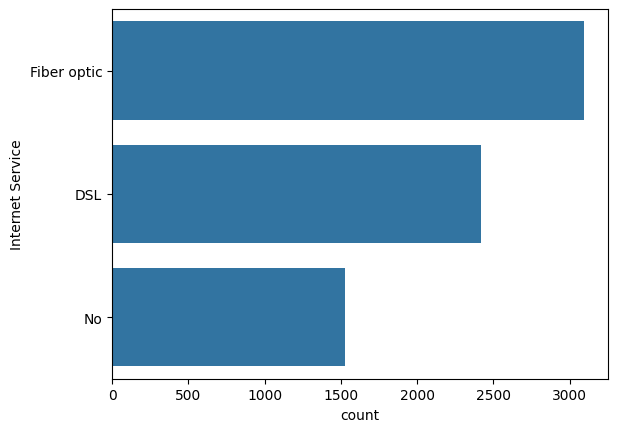

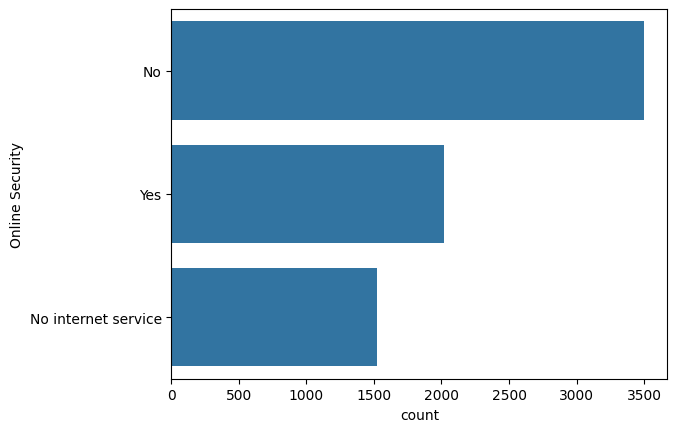

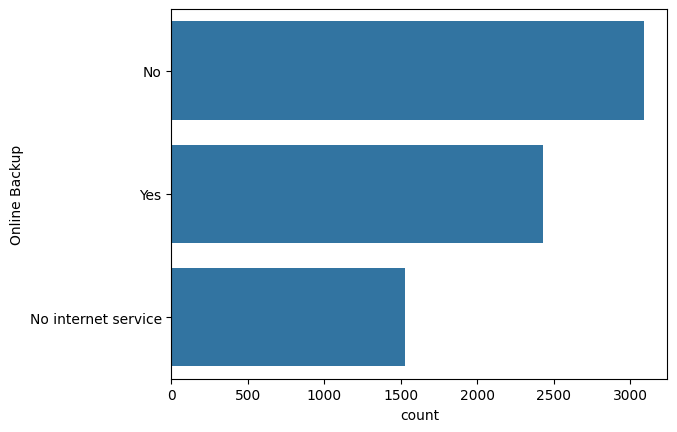

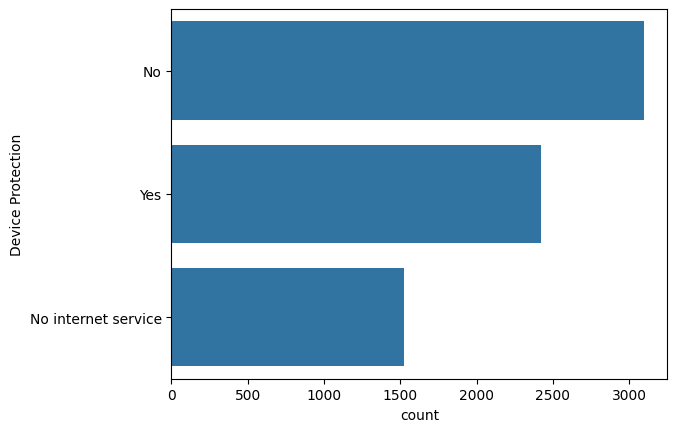

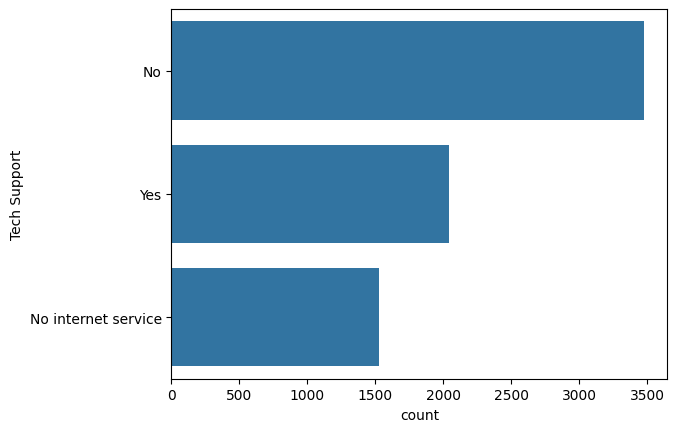

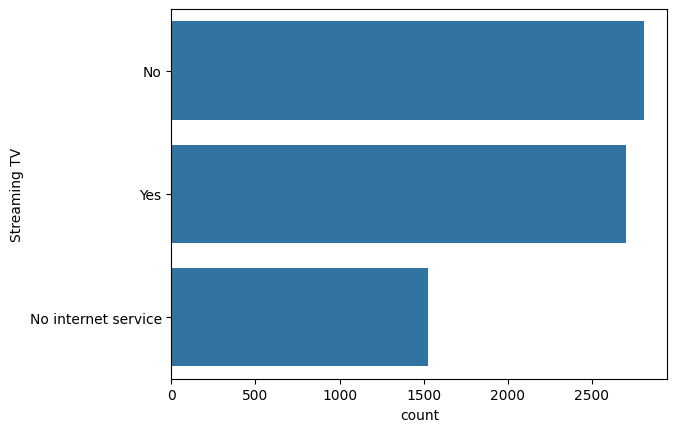

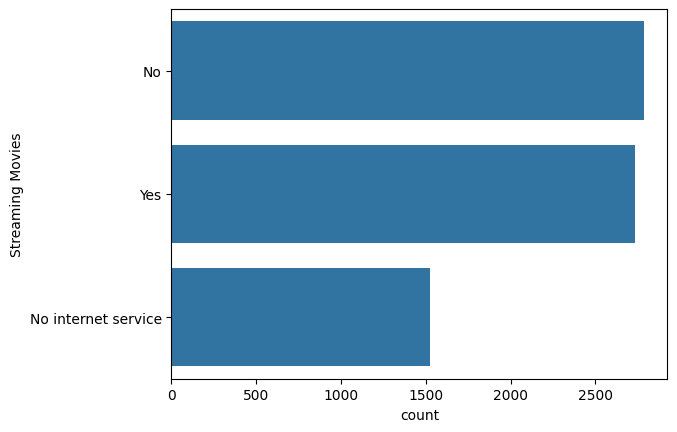

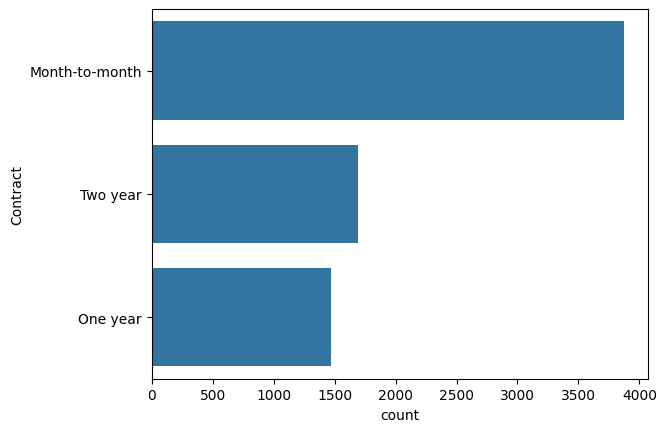

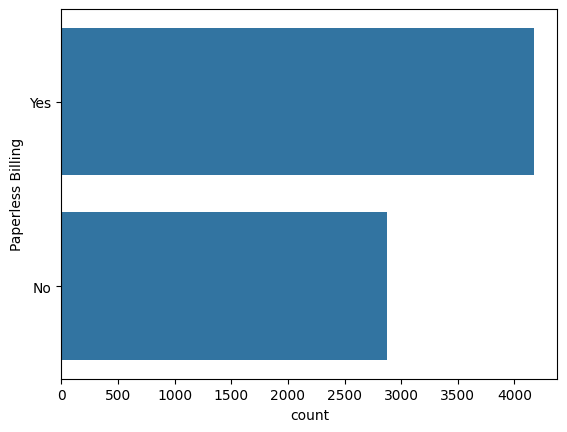

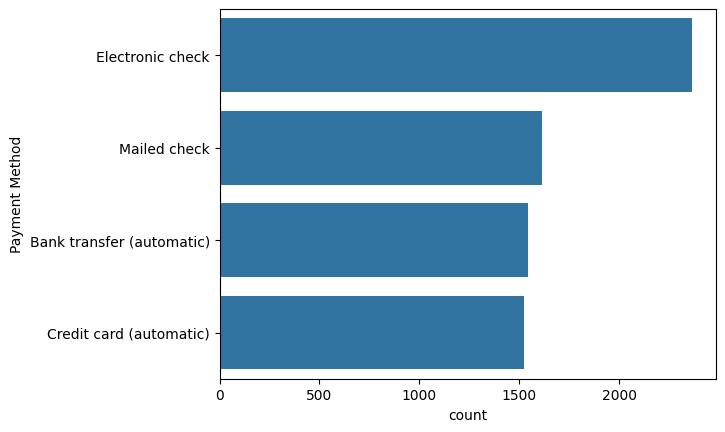

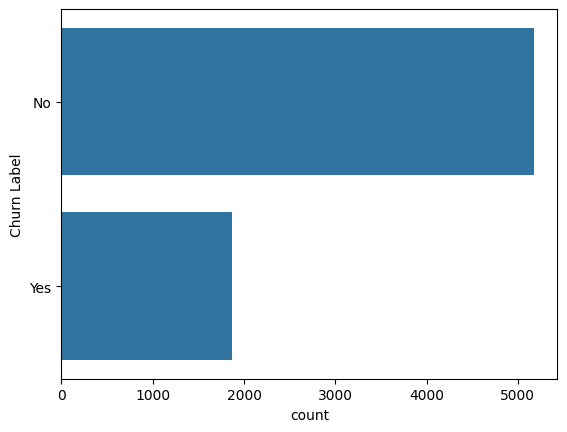

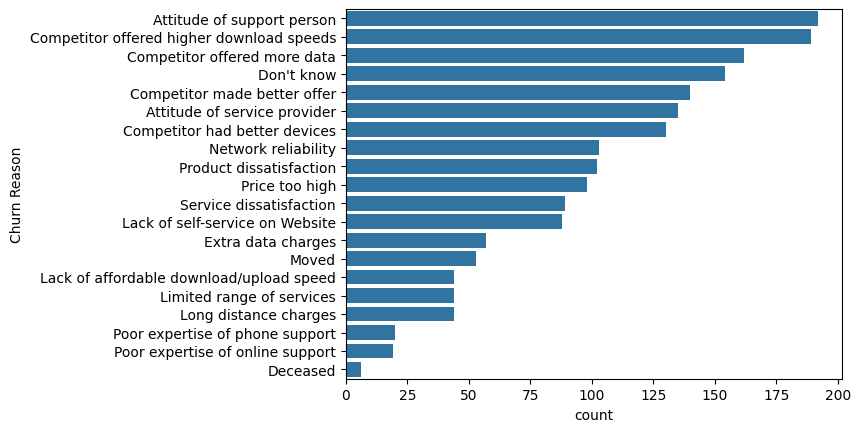

In [36]:
for cat in df_limpio.select_dtypes(include=['object']).columns:
    plt.figure()
    sns.countplot(data=df, y=cat, order=df_limpio[cat].value_counts().index)
    plt.show();

## Paso 6: Análisis bivariado.

Se va a suponer que con este archivo de datos se desea hacer un modelo de aprendizaje de máquina que prediga la **Churn Value**.


Mediante análisis de gráficas responda las siguientes preguntas:

- ¿Cómo se relaciona cada una de las variables cuantitativas con la variable que se desea predecir?
- ¿Cómo se relaciona cada una de las variables cualitativas con la variable que se desea predecir?
- De acuerdo con estos análisis, ¿cuáles variables parecerían ser buenas predictoras, y cuáles no?


#### <span style="color:green"> 1. Asi se relacionan las variables cuantitativas</span>


--- Análisis Estadístico de Zip Code por Churn Value ---


,count,mean,std,min,25%,50%,75%,max
Churn Value,,,,,,,,
0,5174.0,93518.212215,1868.429496,90001.0,92091.0,93551.0,95345.75,96148.0
1,1869.0,93532.352595,1858.939970,90001.0,92105.0,93554.0,95358.00,96161.0


/var/folders/_l/gfl4k6dx59qdvqn1k_hr93f40000gp/T/ipykernel_1965/1388986184.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_limpio, x='Churn Value', y=var, palette='Set2')


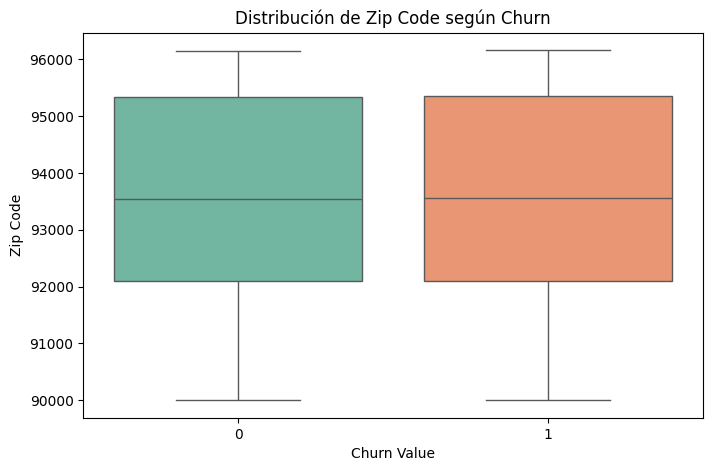

--------------------------------------------------
--- Análisis Estadístico de Latitude por Churn Value ---


,count,mean,std,min,25%,50%,75%,max
Churn Value,,,,,,,,
0,5174.0,36.287436,2.449340,32.555828,34.029076,36.414414,38.227285,41.962127
1,1869.0,36.268614,2.473911,32.555828,34.038983,36.298780,38.200231,41.962127


/var/folders/_l/gfl4k6dx59qdvqn1k_hr93f40000gp/T/ipykernel_1965/1388986184.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_limpio, x='Churn Value', y=var, palette='Set2')


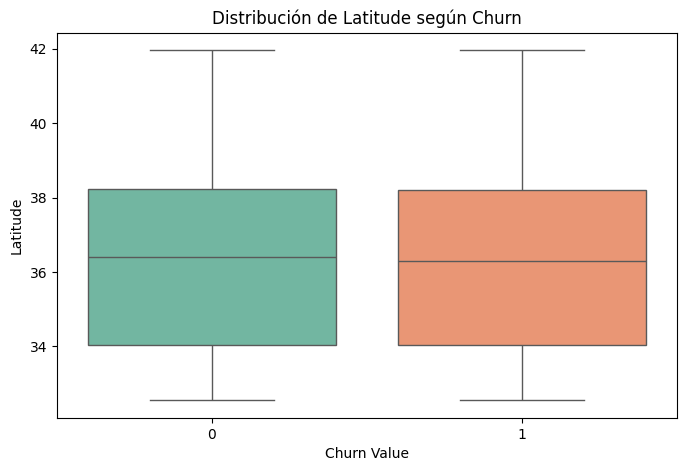

--------------------------------------------------
--- Análisis Estadístico de Longitude por Churn Value ---


,count,mean,std,min,25%,50%,75%,max
Churn Value,,,,,,,,
0,5174.0,-119.804838,2.156210,-124.301372,-121.823565,-119.739935,-118.049237,-114.192901
1,1869.0,-119.782388,2.163024,-124.301372,-121.799917,-119.711868,-118.020188,-114.192901


/var/folders/_l/gfl4k6dx59qdvqn1k_hr93f40000gp/T/ipykernel_1965/1388986184.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_limpio, x='Churn Value', y=var, palette='Set2')


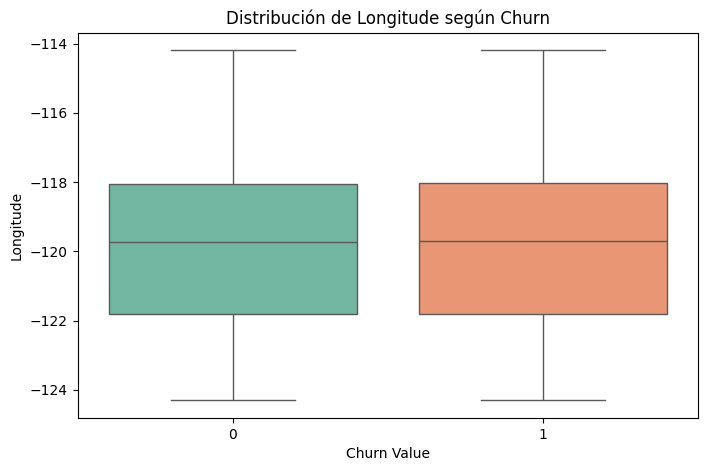

--------------------------------------------------
--- Análisis Estadístico de Tenure Months por Churn Value ---


,count,mean,std,min,25%,50%,75%,max
Churn Value,,,,,,,,
0,5174.0,37.569965,24.113777,0.0,15.0,38.0,61.0,72.0
1,1869.0,17.979133,19.531123,1.0,2.0,10.0,29.0,72.0


/var/folders/_l/gfl4k6dx59qdvqn1k_hr93f40000gp/T/ipykernel_1965/1388986184.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_limpio, x='Churn Value', y=var, palette='Set2')


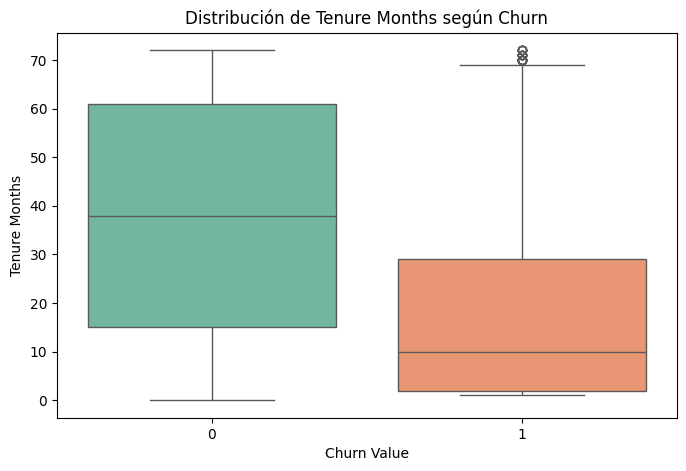

--------------------------------------------------
--- Análisis Estadístico de Monthly Charges por Churn Value ---


,count,mean,std,min,25%,50%,75%,max
Churn Value,,,,,,,,
0,5174.0,61.265124,31.092648,18.25,25.10,64.425,88.4,118.75
1,1869.0,74.441332,24.666053,18.85,56.15,79.650,94.2,118.35


/var/folders/_l/gfl4k6dx59qdvqn1k_hr93f40000gp/T/ipykernel_1965/1388986184.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_limpio, x='Churn Value', y=var, palette='Set2')


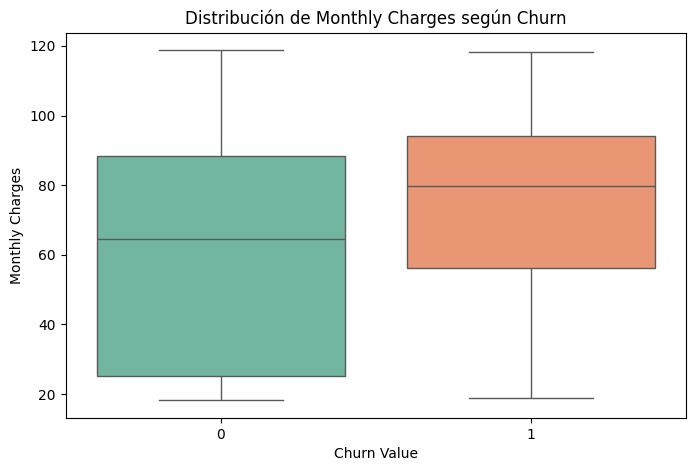

--------------------------------------------------
--- Análisis Estadístico de Total Charges por Churn Value ---


,count,mean,std,min,25%,50%,75%,max
Churn Value,,,,,,,,
0,5163.0,2555.344141,2329.456984,18.80,577.825,1683.60,4264.125,8672.45
1,1869.0,1531.796094,1890.822994,18.85,134.500,703.55,2331.300,8684.80


/var/folders/_l/gfl4k6dx59qdvqn1k_hr93f40000gp/T/ipykernel_1965/1388986184.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_limpio, x='Churn Value', y=var, palette='Set2')


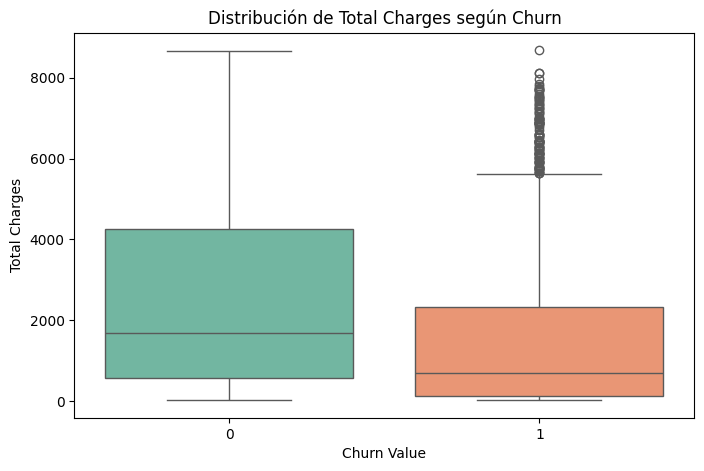

--------------------------------------------------
--- Análisis Estadístico de Churn Score por Churn Value ---


,count,mean,std,min,25%,50%,75%,max
Churn Value,,,,,,,,
0,5174.0,50.098183,17.702277,5.0,35.0,50.0,66.0,80.0
1,1869.0,82.510433,10.328570,65.0,74.0,82.0,91.0,100.0


/var/folders/_l/gfl4k6dx59qdvqn1k_hr93f40000gp/T/ipykernel_1965/1388986184.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_limpio, x='Churn Value', y=var, palette='Set2')


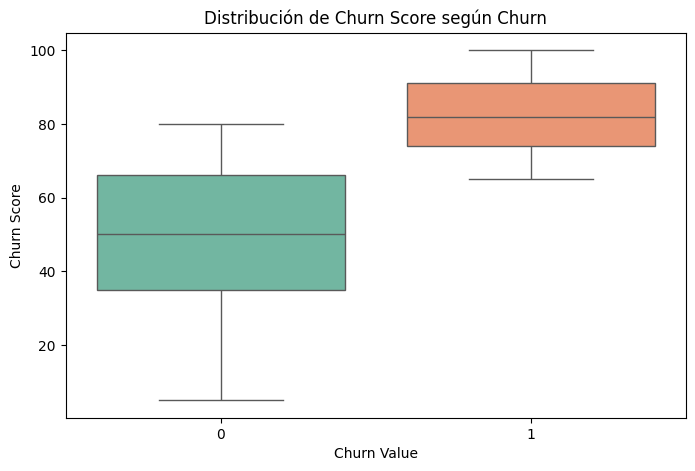

--------------------------------------------------
--- Análisis Estadístico de CLTV por Churn Value ---


,count,mean,std,min,25%,50%,75%,max
Churn Value,,,,,,,,
0,5174.0,4490.921337,1167.703198,2003.0,3643.75,4620.0,5434.75,6500.0
1,1869.0,4149.414660,1189.370707,2003.0,3101.00,4238.0,5166.00,6484.0


/var/folders/_l/gfl4k6dx59qdvqn1k_hr93f40000gp/T/ipykernel_1965/1388986184.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_limpio, x='Churn Value', y=var, palette='Set2')


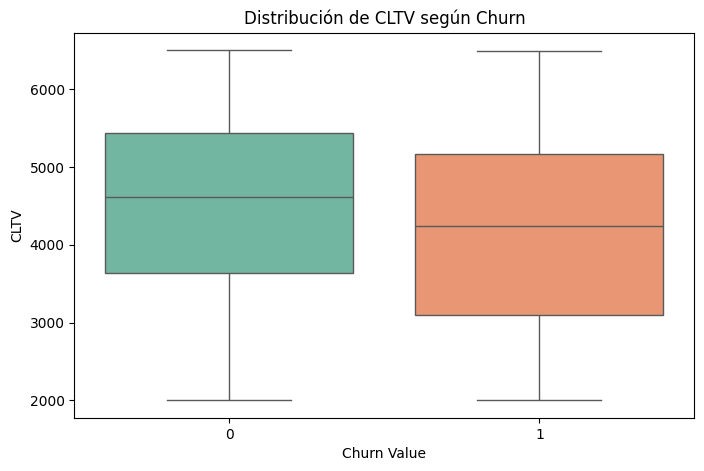

--------------------------------------------------


In [39]:
num_vars = df_limpio.select_dtypes(include=['number']).columns.tolist()
if 'Churn Value' in num_vars: num_vars.remove('Churn Value')

for var in num_vars:
    print(f"--- Análisis Estadístico de {var} por Churn Value ---")
    # El describe agrupado que mencionaste (nos da media, min, max, etc.)
    display(df_limpio.groupby('Churn Value')[var].describe())
    
    # El Boxplot adaptado (Categoría en X, Número en Y)
    plt.figure(figsize=(8, 5))
    sns.boxplot(data=df_limpio, x='Churn Value', y=var, palette='Set2')
    plt.title(f'Distribución de {var} según Churn')
    plt.show()
    print("-" * 50)

#### <span style="color:green"> 2.Asi de relaciona con las variables cualitativas</span>


--- Proporción de Churn por Gender ---


Churn Value,0,1
Gender,,
Female,73.079128,26.920872
Male,73.839662,26.160338


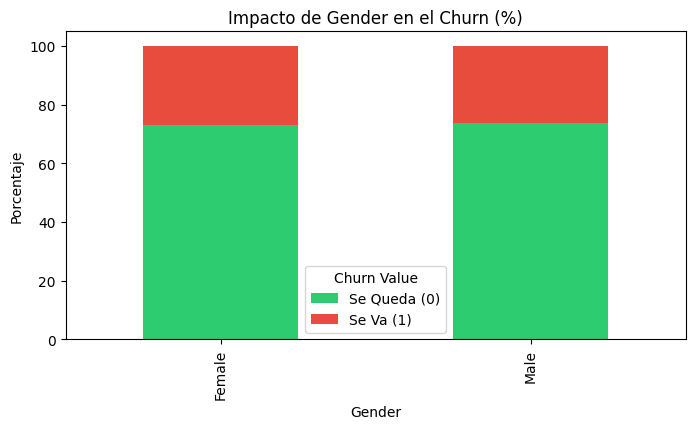

--------------------------------------------------
--- Proporción de Churn por Senior Citizen ---


Churn Value,0,1
Senior Citizen,,
No,76.393832,23.606168
Yes,58.318739,41.681261


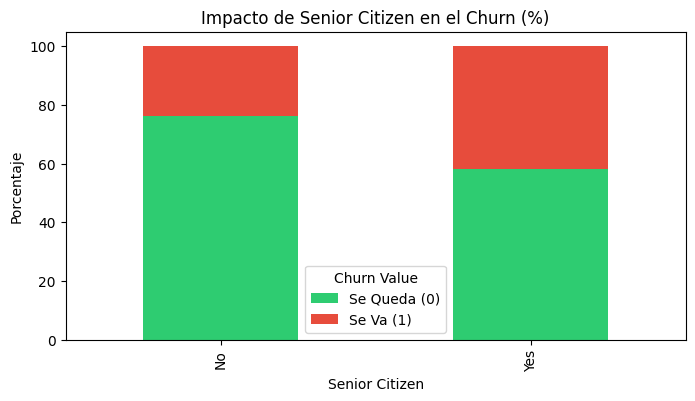

--------------------------------------------------
--- Proporción de Churn por Partner ---


Churn Value,0,1
Partner,,
No,67.042021,32.957979
Yes,80.335097,19.664903


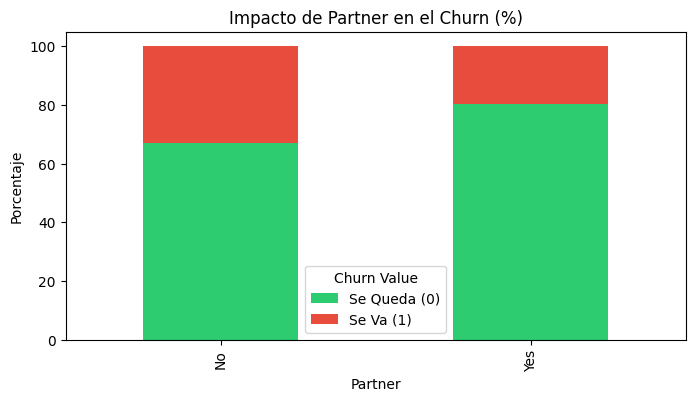

--------------------------------------------------
--- Proporción de Churn por Dependents ---


Churn Value,0,1
Dependents,,
No,67.448301,32.551699
Yes,93.484942,6.515058


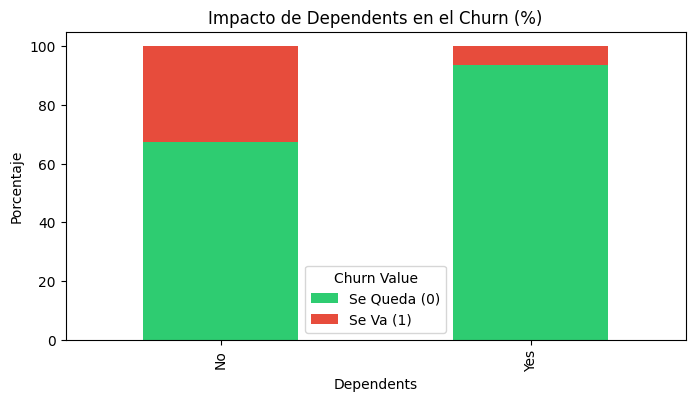

--------------------------------------------------
--- Proporción de Churn por Phone Service ---


Churn Value,0,1
Phone Service,,
No,75.073314,24.926686
Yes,73.290363,26.709637


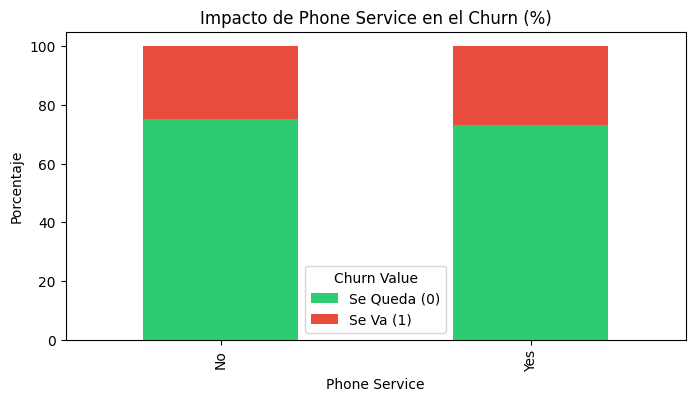

--------------------------------------------------
--- Proporción de Churn por Multiple Lines ---


Churn Value,0,1
Multiple Lines,,
No,74.955752,25.044248
No phone service,75.073314,24.926686
Yes,71.390104,28.609896


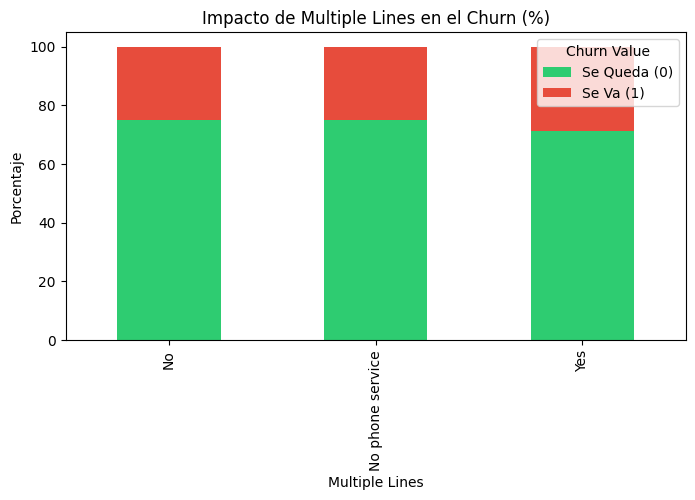

--------------------------------------------------
--- Proporción de Churn por Internet Service ---


Churn Value,0,1
Internet Service,,
DSL,81.040892,18.959108
Fiber optic,58.107235,41.892765
No,92.595020,7.404980


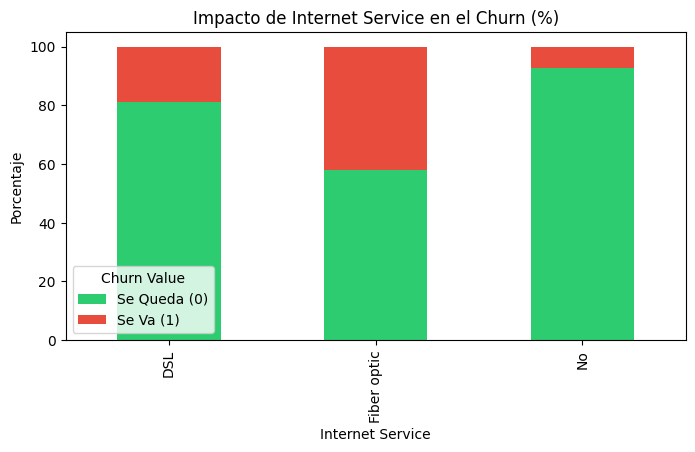

--------------------------------------------------
--- Proporción de Churn por Online Security ---


Churn Value,0,1
Online Security,,
No,58.233276,41.766724
No internet service,92.595020,7.404980
Yes,85.388806,14.611194


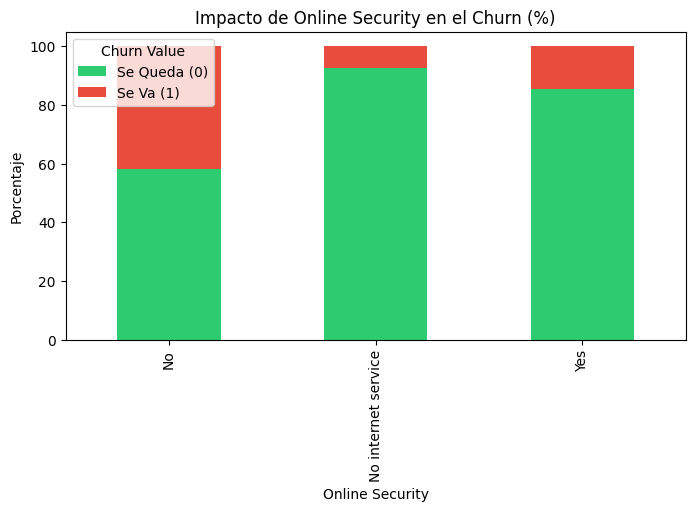

--------------------------------------------------
--- Proporción de Churn por Online Backup ---


Churn Value,0,1
Online Backup,,
No,60.071244,39.928756
No internet service,92.595020,7.404980
Yes,78.468506,21.531494


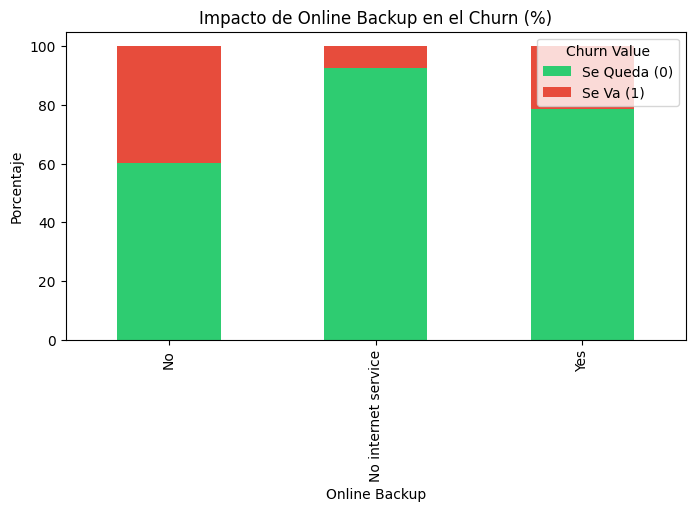

--------------------------------------------------
--- Proporción de Churn por Device Protection ---


Churn Value,0,1
Device Protection,,
No,60.872375,39.127625
No internet service,92.595020,7.404980
Yes,77.497936,22.502064


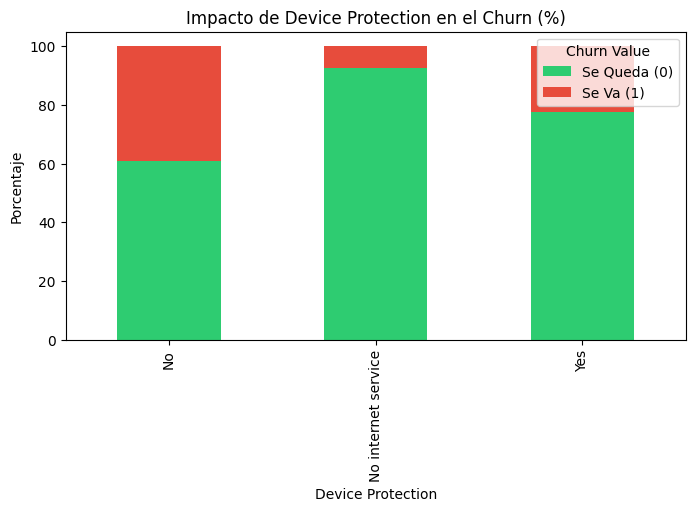

--------------------------------------------------
--- Proporción de Churn por Tech Support ---


Churn Value,0,1
Tech Support,,
No,58.364526,41.635474
No internet service,92.595020,7.404980
Yes,84.833659,15.166341


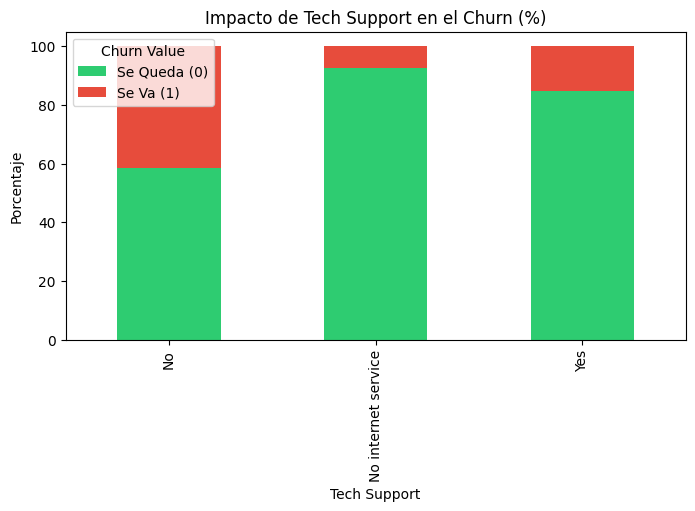

--------------------------------------------------
--- Proporción de Churn por Streaming TV ---


Churn Value,0,1
Streaming TV,,
No,66.476868,33.523132
No internet service,92.595020,7.404980
Yes,69.929812,30.070188


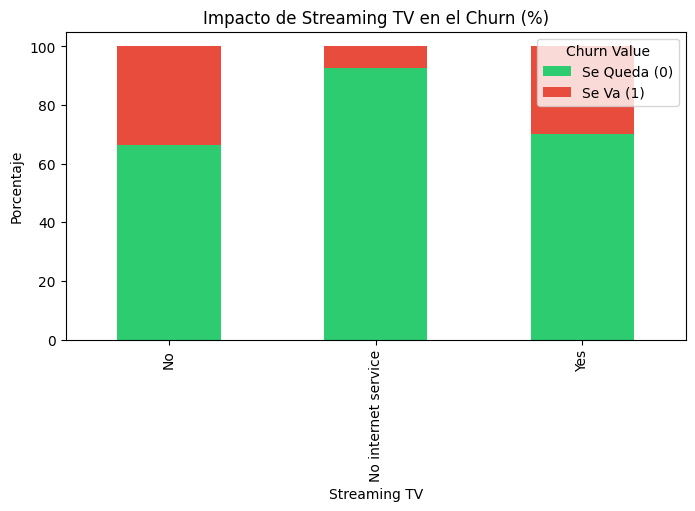

--------------------------------------------------
--- Proporción de Churn por Streaming Movies ---


Churn Value,0,1
Streaming Movies,,
No,66.319569,33.680431
No internet service,92.595020,7.404980
Yes,70.058565,29.941435


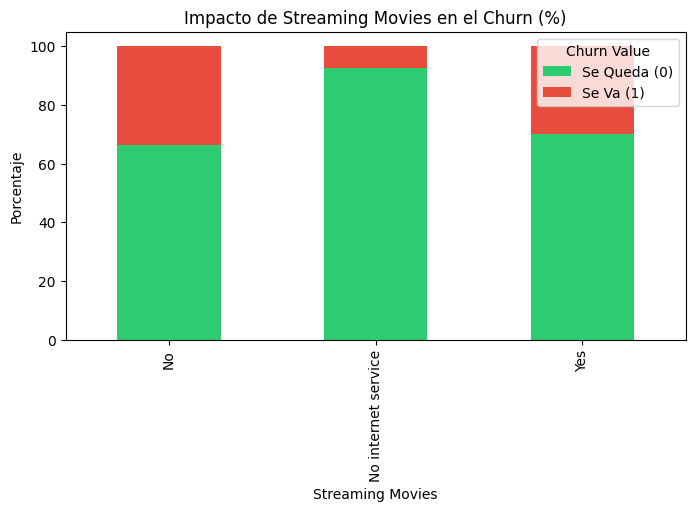

--------------------------------------------------
--- Proporción de Churn por Contract ---


Churn Value,0,1
Contract,,
Month-to-month,57.290323,42.709677
One year,88.730482,11.269518
Two year,97.168142,2.831858


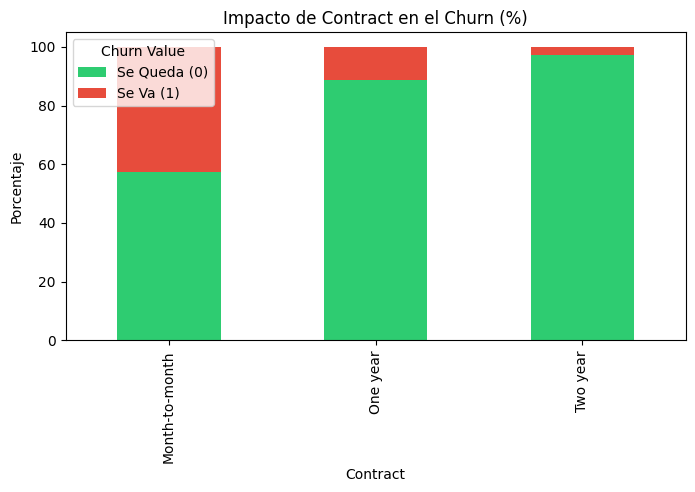

--------------------------------------------------
--- Proporción de Churn por Paperless Billing ---


Churn Value,0,1
Paperless Billing,,
No,83.669916,16.330084
Yes,66.434908,33.565092


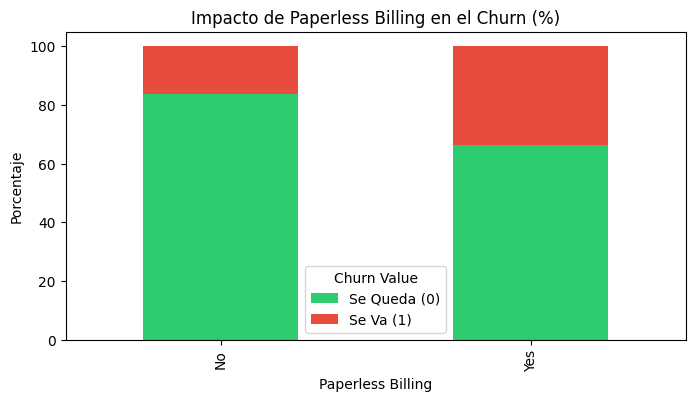

--------------------------------------------------
--- Proporción de Churn por Payment Method ---


Churn Value,0,1
Payment Method,,
Bank transfer (automatic),83.290155,16.709845
Credit card (automatic),84.756899,15.243101
Electronic check,54.714588,45.285412
Mailed check,80.893300,19.106700


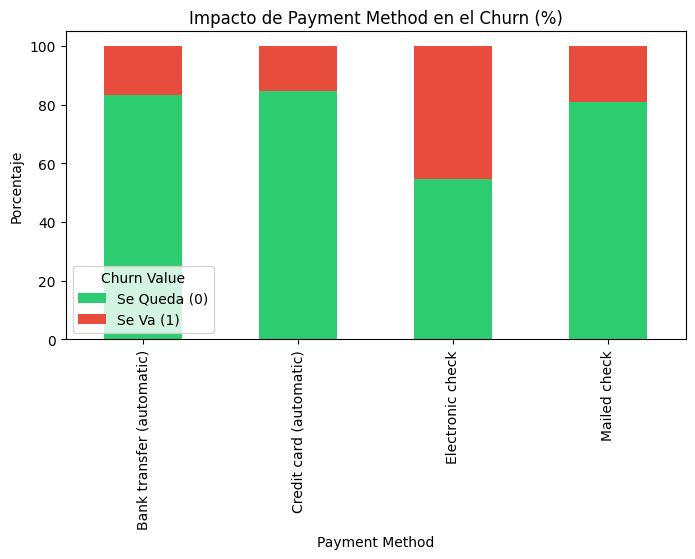

--------------------------------------------------
--- Proporción de Churn por Churn Label ---


Churn Value,0,1
Churn Label,,
No,100.0,0.0
Yes,0.0,100.0


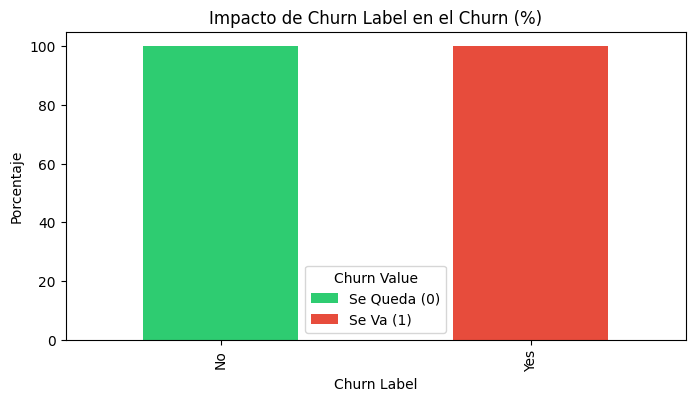

--------------------------------------------------
--- Proporción de Churn por Churn Reason ---


Churn Value,1
Churn Reason,
Attitude of service provider,100.0
Attitude of support person,100.0
Competitor had better devices,100.0
Competitor made better offer,100.0
Competitor offered higher download speeds,100.0
Competitor offered more data,100.0
Deceased,100.0
Don't know,100.0
Extra data charges,100.0


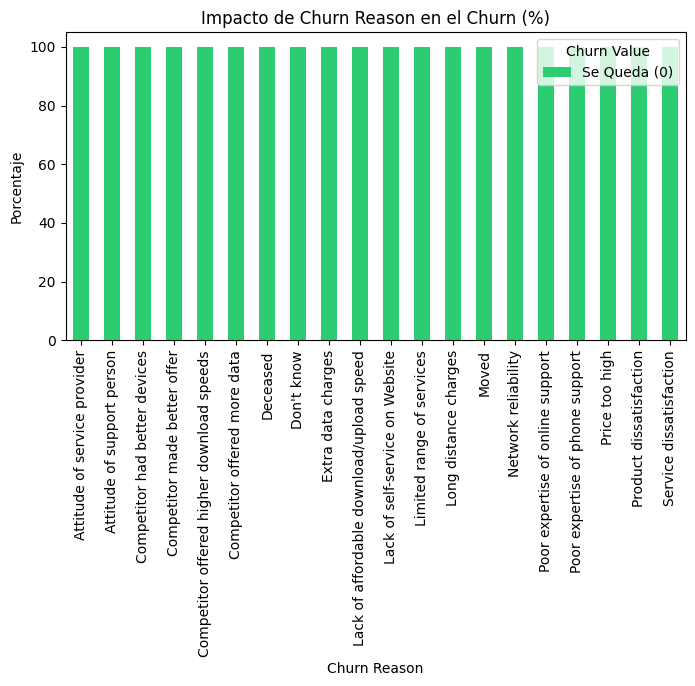

--------------------------------------------------


In [ ]:
# Filtramos las columnas categóricas
cat_vars = df_limpio.select_dtypes(include=['object', 'category']).columns.tolist()
if 'Churn Value' in cat_vars: cat_vars.remove('Churn Value')

for var in cat_vars:
    print(f"--- Proporción de Churn por {var} ---")
    # Crosstab normalizado por índice (filas) para ver porcentajes
    tabla = pd.crosstab(df_limpio[var], df_limpio['Churn Value'], normalize='index') * 100
    display(tabla)
    
    # Un gráfico de barras para visualizar ese crosstab
    tabla.plot(kind='bar', stacked=True, figsize=(8, 4), color=['#2ecc71', '#e74c3c'])
    plt.title(f'Impacto de {var} en el Churn (%)')
    plt.ylabel('Porcentaje')
    plt.legend(title='Churn Value', labels=['Se Queda (0)', 'Se Va (1)'])
    plt.show()
    print("-" * 50)

#### <span style="color:green">  Según este analisis cuales son buenas prediciendo el churn reason estas variable cuantitativas : Tenure months, monthly charges, total charges, churn score,  cltv y las cualitativas son: Senior citizen, partner, dependents, internet service, online security, online backup, .device protection, tech support, streaming tv, streaming movies, contract, , paperless billing, payment method.